# Advanced Analytics

This notebook performs advanced risk analytics,
investor behaviour analysis and mutual fund recommendation modelling.

Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

Load Outputs

In [2]:
processed_dir = Path("../data/processed")

var_cvar = pd.read_csv(
    processed_dir /
    "var_cvar_report.csv"
)

recommendations = pd.read_csv(
    processed_dir /
    "recommendations.csv"
)

cohort = pd.read_csv(
    processed_dir /
    "cohort_analysis.csv"
)

sip = pd.read_csv(
    processed_dir /
    "sip_continuity.csv"
)

hhi = pd.read_csv(
    processed_dir /
    "hhi_report.csv"
)

VaR Distribution

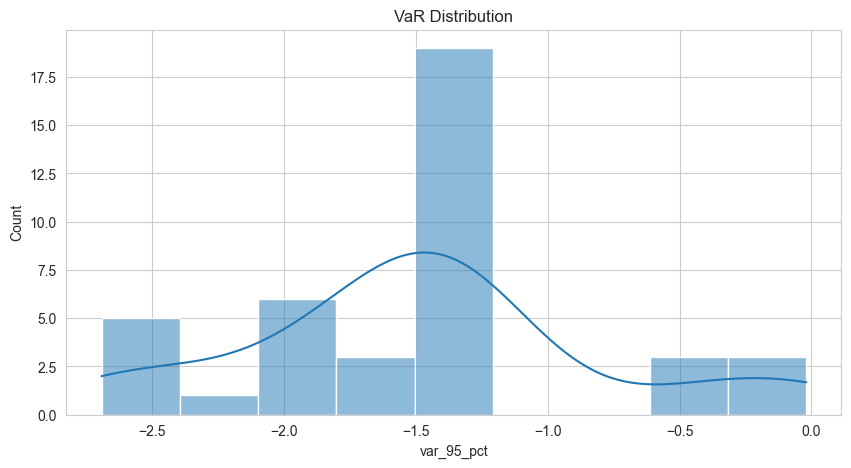

In [3]:
plt.figure(figsize=(10,5))

sns.histplot(
    var_cvar["var_95_pct"],
    kde=True
)

plt.title(
    "VaR Distribution"
)

plt.show()

CVaR Distribution

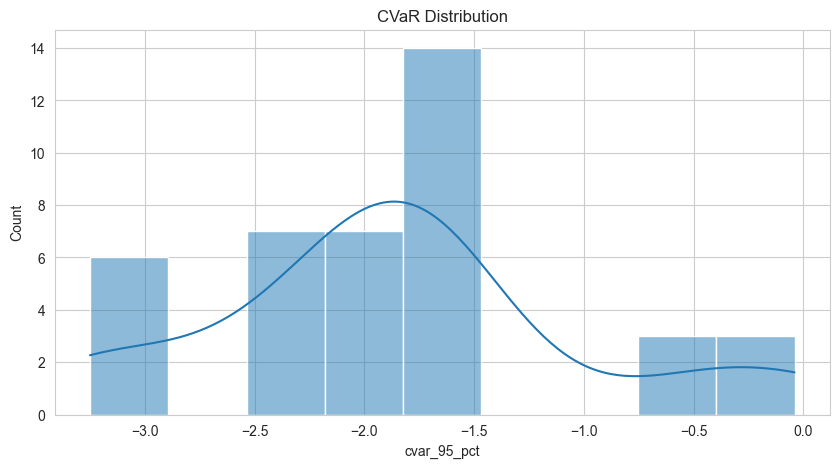

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    var_cvar["cvar_95_pct"],
    kde=True
)

plt.title(
    "CVaR Distribution"
)

plt.show()

Highest Risk Funds

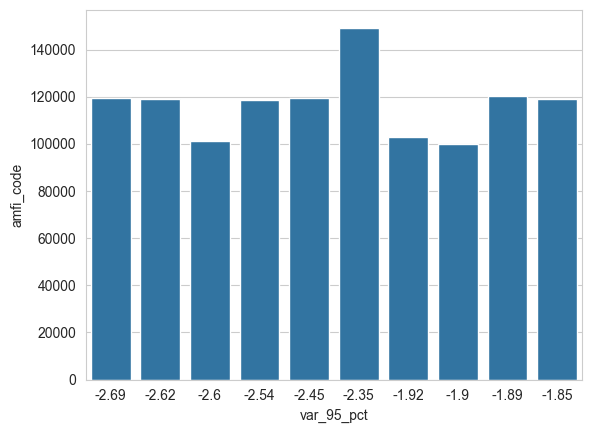

In [5]:
top_risk = (
    var_cvar
    .sort_values(
        "var_95_pct"
    )
    .head(10)
)

sns.barplot(
    data=top_risk,
    x="var_95_pct",
    y="amfi_code"
)

plt.show()

Cohort Investment Trend

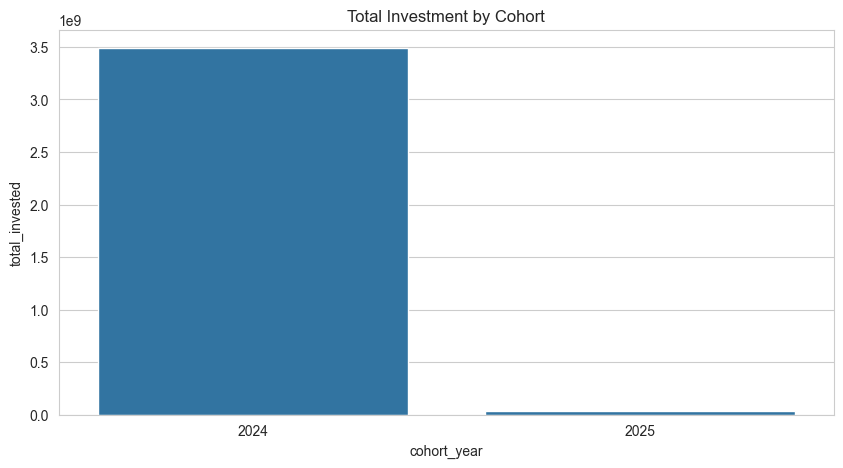

In [6]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=cohort,
    x="cohort_year",
    y="total_invested"
)

plt.title(
    "Total Investment by Cohort"
)

plt.show()

Average SIP Amount by Cohort

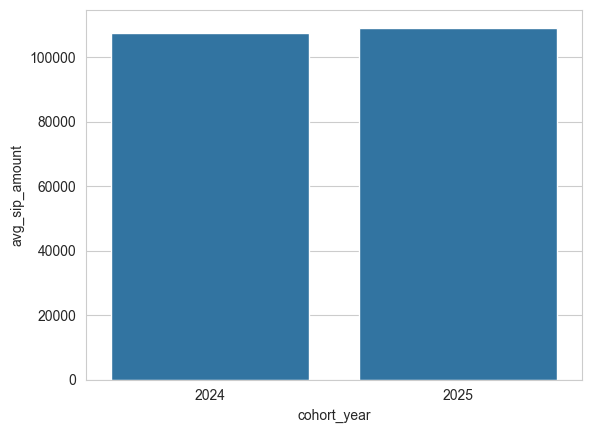

In [7]:
sns.barplot(
    data=cohort,
    x="cohort_year",
    y="avg_sip_amount"
)

plt.show()

SIP Continuity Status

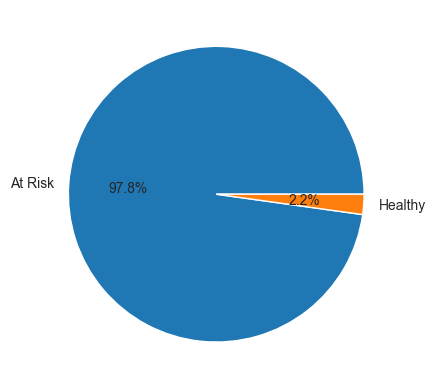

In [8]:
sip[
    "status"
].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

Average SIP Gap

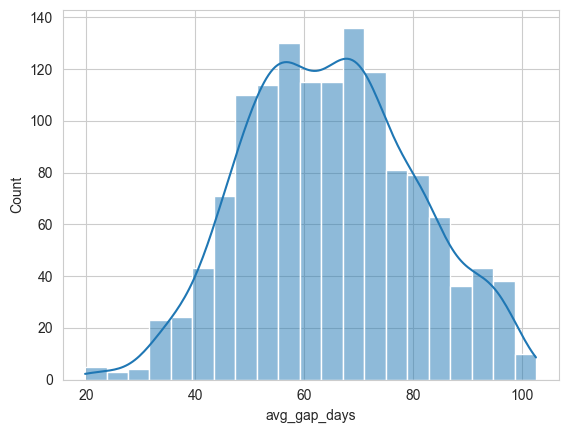

In [9]:
sns.histplot(
    sip["avg_gap_days"],
    kde=True
)

plt.show()

Risk Bucket Distribution

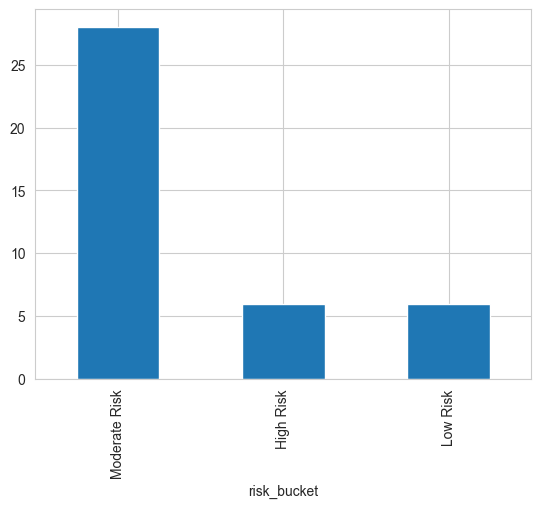

In [10]:
recommendations[
    "risk_bucket"
].value_counts().plot(
    kind="bar"
)

plt.show()

Top Recommended Funds

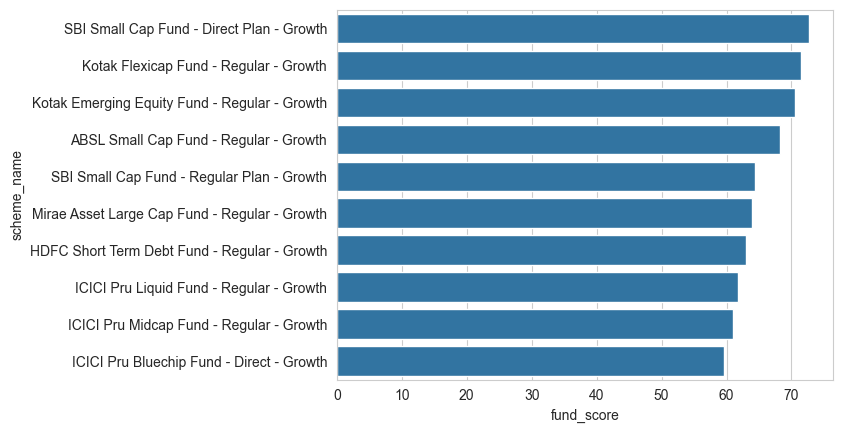

In [11]:
top10 = (
    recommendations
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(10)
)

sns.barplot(
    data=top10,
    x="fund_score",
    y="scheme_name"
)

plt.show()

Sector HHI Distribution

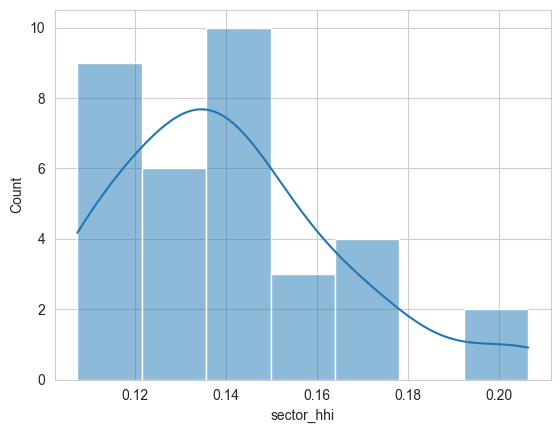

In [12]:
sns.histplot(
    hhi["sector_hhi"],
    kde=True
)

plt.show()

Most Concentrated Funds

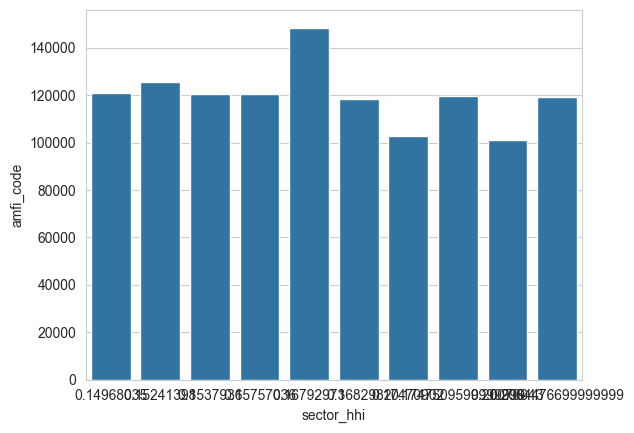

In [13]:
top_hhi = (
    hhi
    .sort_values(
        "sector_hhi",
        ascending=False
    )
    .head(10)
)

sns.barplot(
    data=top_hhi,
    x="sector_hhi",
    y="amfi_code"
)

plt.show()

Rolling Sharpe Chart

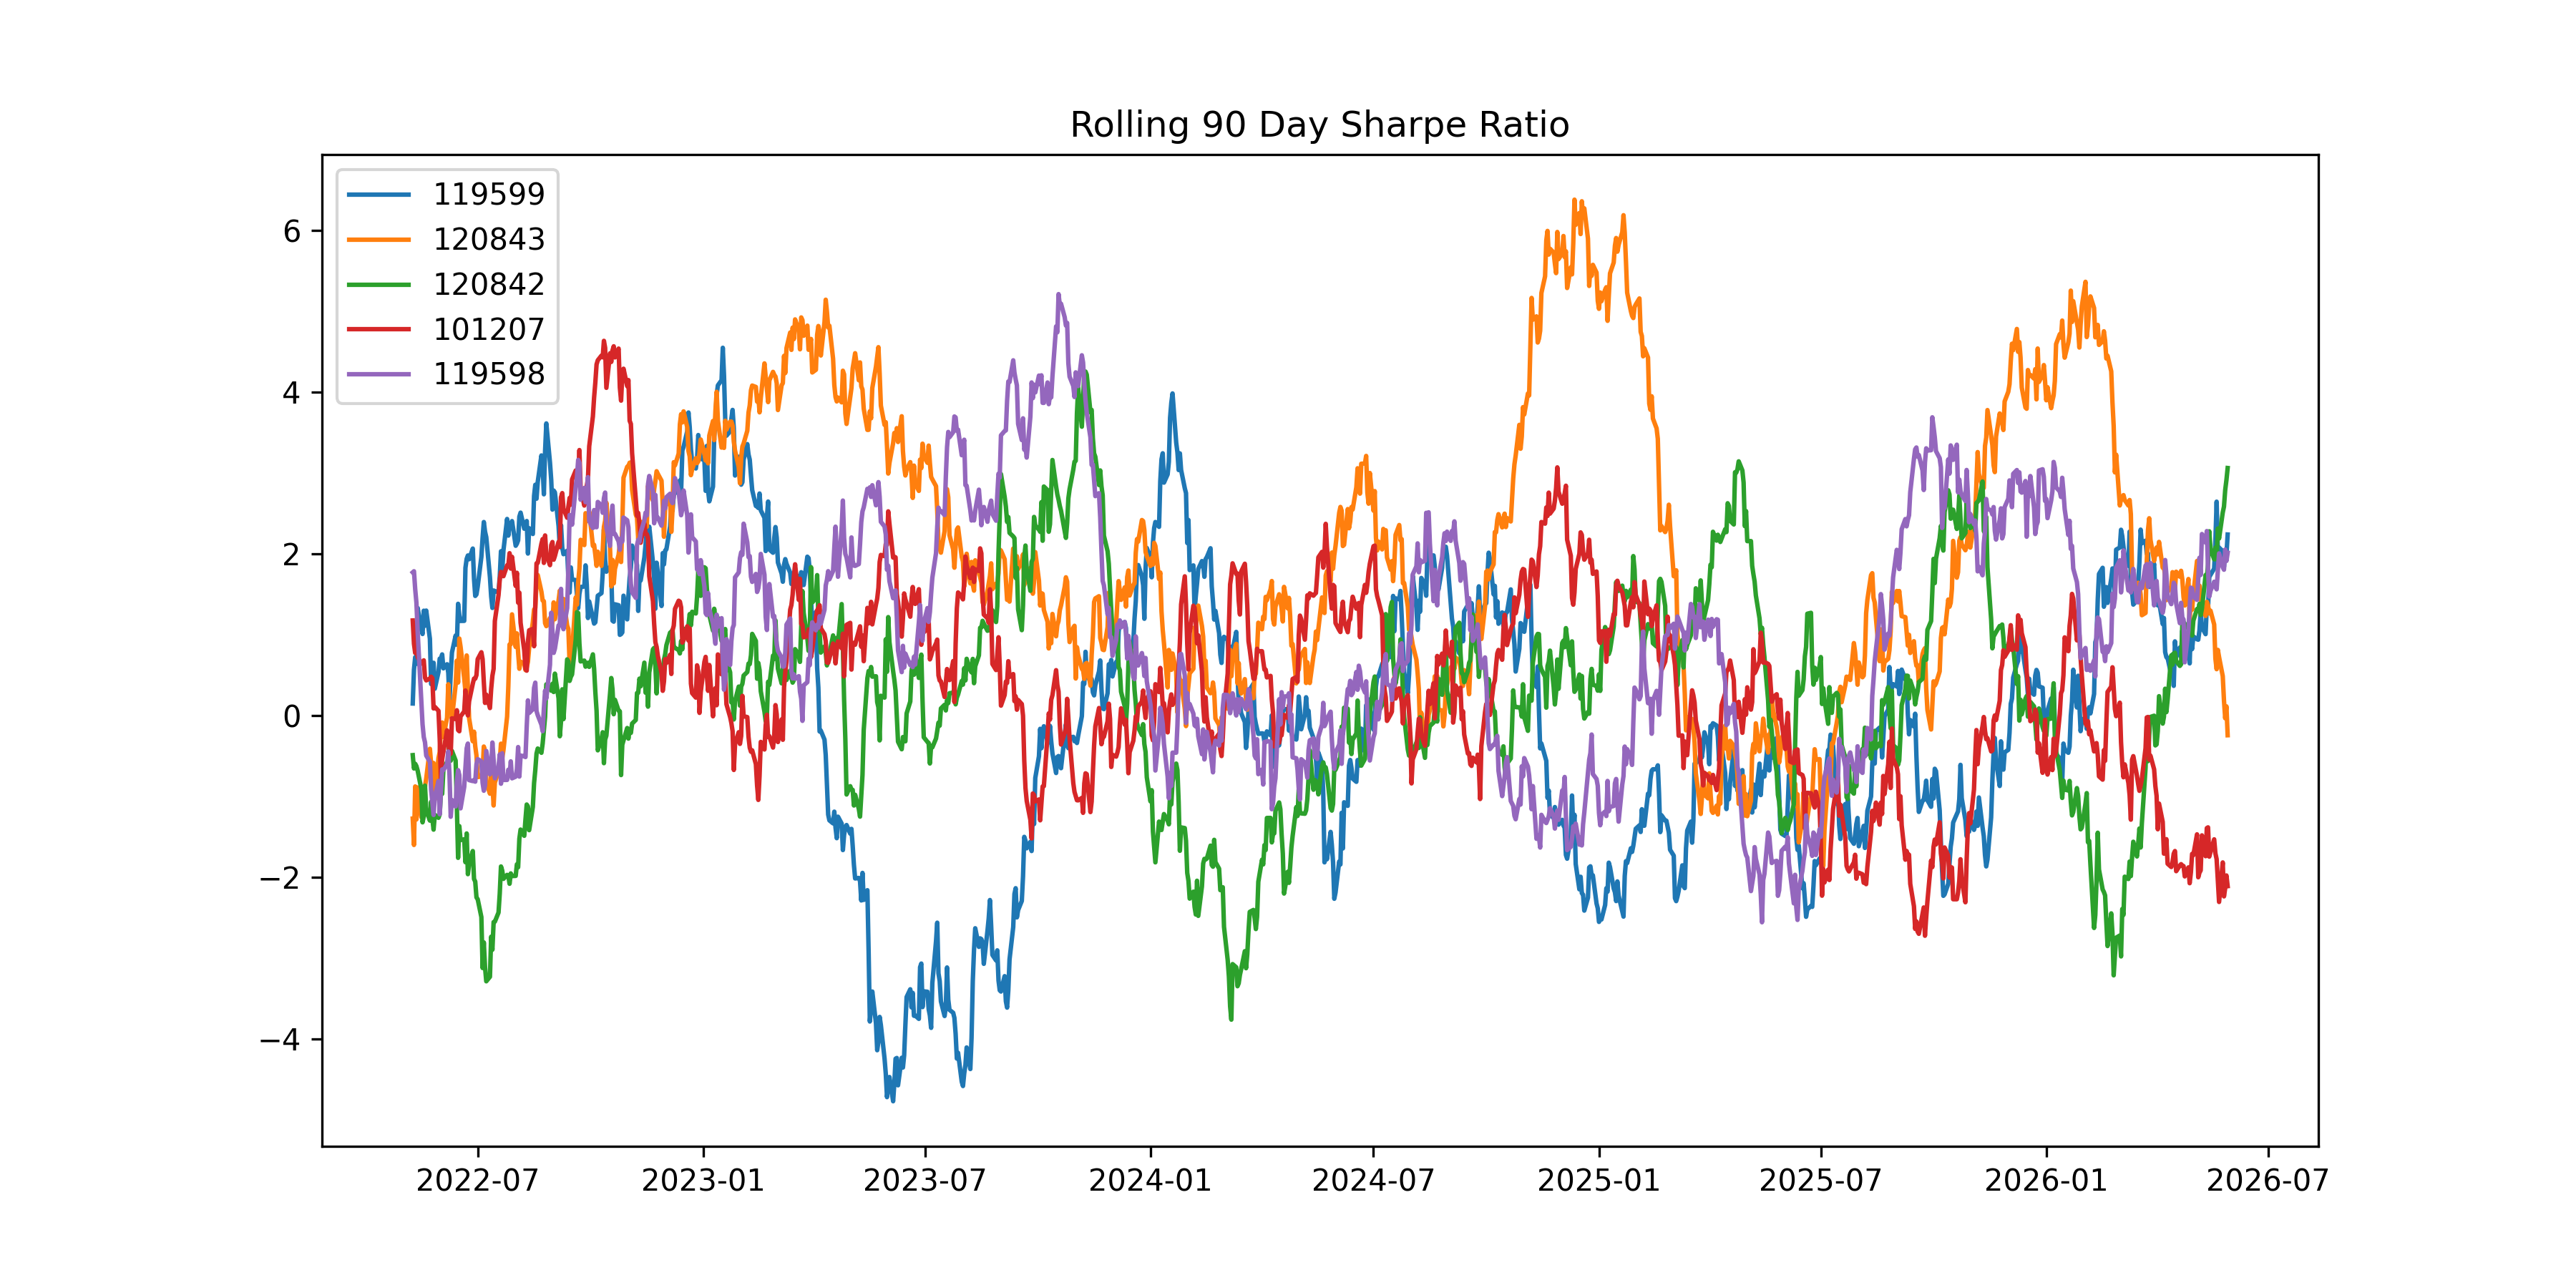

In [14]:
from IPython.display import Image

Image(
    "../reports/rolling_sharpe_chart.png"
)

Recommendation Table

In [15]:
recommendations[
[
    "scheme_name",
    "fund_score",
    "risk_bucket"
]
].head(10)

,scheme_name,fund_score,risk_bucket
0,SBI Small Cap Fund - Direct Plan - Growth,72.75,High Risk
1,Kotak Flexicap Fund - Regular - Growth,71.50,Moderate Risk
2,Kotak Emerging Equity Fund - Regular - Growth,70.50,Moderate Risk
3,ABSL Small Cap Fund - Regular - Growth,68.25,High Risk
4,SBI Small Cap Fund - Regular Plan - Growth,64.38,High Risk
5,Mirae Asset Large Cap Fund - Regular - Growth,63.94,Moderate Risk
6,HDFC Short Term Debt Fund - Regular - Growth,63.00,Low Risk
7,ICICI Pru Liquid Fund - Regular - Growth,61.75,Low Risk
8,ICICI Pru Midcap Fund - Regular - Growth,61.00,Moderate Risk
9,ICICI Pru Bluechip Fund - Direct - Growth,59.62,Moderate Risk


VaR / CVaR Table

In [16]:
var_cvar.head(10)

,amfi_code,var_95_pct,cvar_95_pct,risk_bucket
0,100016,-1.44,-1.81,Moderate Risk
1,100025,-0.38,-0.50,Low Risk
2,100033,-1.90,-2.35,Moderate Risk
3,101206,-1.33,-1.74,Moderate Risk
4,101207,-2.60,-3.25,High Risk
5,101208,-0.03,-0.04,Low Risk
6,102885,-1.26,-1.55,Moderate Risk
7,102886,-1.92,-2.33,Moderate Risk
8,102887,-1.52,-1.94,Moderate Risk
9,118632,-1.40,-1.76,Moderate Risk


Advanced Insights

1. Funds with higher VaR values exhibit greater downside risk.

2. CVaR highlights extreme loss scenarios beyond standard VaR.

3. Recent investor cohorts contribute a large share of total investments.

4. Most SIP investors maintain healthy continuity patterns.

5. A small subset of investors are classified as at-risk due to irregular contributions.

6. High Sharpe ratio funds dominate recommendation rankings.

7. Risk buckets provide effective segmentation for investor suitability.

8. Some funds exhibit highly concentrated sector allocations based on HHI.

9. Diversified funds generally show lower concentration risk.

10. Combining risk and return metrics improves recommendation quality.

Final Summary

## Conclusion

Advanced analytics successfully evaluated downside risk,
investor behaviour, SIP continuity and fund concentration.

The recommendation engine identifies suitable funds based on
risk characteristics and overall performance metrics.